# v2 固定位置模式仿真笔记本

本笔记本模拟手术机器人器械护士助手的 **v2 固定位置模式**，在无硬件环境下验证核心逻辑、可视化机械臂轨迹、并提供端到端流程演示。

### v1 vs v2 核心区别

| | v1 (当前) | v2 (固定位置模式) |
|---|---|---|
| 定位方式 | YOLO检测 + 手眼标定 | 固定槽位 + 示教坐标查表 |
| 依赖 | 摄像头、YOLO模型、标定矩阵 | instruments.ini 配置文件 |
| 耗时 | 标定1小时 + 识别延迟 | 示教5分钟，运行零延迟 |
| 稳定性 | 受光照/摆放影响大 | 坐标固定，完全可复现 |

### 笔记本结构
- **Part 1** (Cell 2-6): v2 核心逻辑验证
- **Part 2** (Cell 7-10): 3D 轨迹可视化
- **Part 3** (Cell 11-15): 端到端流程演示

## Cell 1: 环境初始化与全局常量

所有常量均直接提取自生产代码 `robotConfig.ini`、`Constants.py`、`gripper_config.py`。

In [16]:
# ============================================================
# Cell 1: 环境初始化
# ============================================================
import configparser
import ast
import io
import math
import time
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# ---------- 全局常量 (来源: robotConfig.ini) ----------
TARGET_POINT = [0, -50.2, -67.3, 112.5, 90, -90, 1]    # 递送目标位置 (关节模式)
RESET_POINT = [0, 32.6, -129.1, 6.7, 90, -90, 1]       # 初始/复位位置 (关节模式)

# ---------- 运动参数 (来源: RobotController.robotMove()) ----------
Z_HOVER = 150    # mm, 悬停高度偏移
Z_GRASP = 1      # mm, 抓取高度偏移
FIXED_RX = -180  # 度, 固定X轴旋转 (末端朝下)
FIXED_RY = 0     # 度, 固定Y轴旋转

# ---------- 器械映射 (来源: Constants.py) ----------
INSTRUMENT_MAP = {"0": "刀柄", "1": "镊子", "2": "剪刀", "3": "持针钳"}

# ---------- 夹爪预设 (来源: gripper_config.py) ----------
GRIPPER_PRESETS = {
    -1: {"open": 800, "close": 20, "force": 800},
     0: {"open": 400, "close": 20, "force": 800},
     1: {"open": 600, "close": 10, "force": 980},
     2: {"open": 500, "close": 40, "force": 550},
     3: {"open": 500, "close": 10, "force": 800},
}

# ---------- 手眼标定矩阵 (来源: RobotCalibrateUtil.py, 用于 v1 对比) ----------
R1 = np.array([[-9.99801479e-01, 1.99246458e-02, 1.09910175e-04],
               [ 1.99247862e-02, 9.99800396e-01, 1.47357936e-03],
               [-8.05276895e-05, 1.47547676e-03,-9.99998908e-01]])
T1 = np.array([[318.67681045], [-1074.33196951], [-44.34858293]])
k1 = 1.2498330321889395

print("环境初始化完成")
print(f"复位点(关节): {RESET_POINT}")
print(f"递送点(关节): {TARGET_POINT}")
print(f"器械种类: {list(INSTRUMENT_MAP.values())}")

环境初始化完成
复位点(关节): [0, 32.6, -129.1, 6.7, 90, -90, 1]
递送点(关节): [0, -50.2, -67.3, 112.5, 90, -90, 1]
器械种类: ['刀柄', '镊子', '剪刀', '持针钳']


---
# Part 1: v2 核心逻辑验证

## Cell 2: instruments.ini 配置格式与加载

v2 的核心配置文件。每种器械对应一个固定槽位，记录:
- 机械臂笛卡尔坐标 `[x, y, z, rz]` (mm/度)
- 夹爪参数 `{open, close, force}`

坐标范围参考手眼标定 B 矩阵的实际样本值 (X:-450~70, Y:-800~-530, Z:-50~-48)。

In [17]:
# ============================================================
# Cell 2: instruments.ini 配置格式定义与加载
# 对标: Constants.init() + configparser 读取 robotConfig.ini
# ============================================================

INSTRUMENTS_INI_CONTENT = """
[mode]
locate_mode = fixed

[instruments]
mapping = {"0": "刀柄", "1": "镊子", "2": "剪刀", "3": "持针钳"}

[positions]
; 格式: [x, y, z, rz]  笛卡尔坐标(mm) + 末端偏转角(度)
; 坐标来源: 示教工具(teach_tool.py)录入
0 = [-350.0, -600.0, -48.5, 45.0]
1 = [-200.0, -650.0, -48.0, 30.0]
2 = [-100.0, -700.0, -49.0, 60.0]
3 = [50.0, -580.0, -48.8, 15.0]

[gripper]
0 = {"open": 400, "close": 20, "force": 800}
1 = {"open": 600, "close": 10, "force": 980}
2 = {"open": 500, "close": 40, "force": 550}
3 = {"open": 500, "close": 10, "force": 800}
"""

@dataclass
class InstrumentConfig:
    """单个器械的完整配置"""
    id: int
    name: str
    x: float
    y: float
    z: float
    rz: float
    gripper: dict


class ConfigLoader:
    """加载 instruments.ini 配置文件

    对标: Constants.init() 使用 configparser 读取 robotConfig.ini
    """

    def __init__(self, ini_content: str):
        self._config = configparser.ConfigParser()
        self._config.read_string(ini_content)
        self._mapping = ast.literal_eval(self._config.get('instruments', 'mapping'))
        self._instruments = {}
        self._load_all()

    def _load_all(self):
        for str_id, name in self._mapping.items():
            int_id = int(str_id)
            pos = ast.literal_eval(self._config.get('positions', str_id))
            grip = ast.literal_eval(self._config.get('gripper', str_id))
            self._instruments[int_id] = InstrumentConfig(
                id=int_id, name=name,
                x=pos[0], y=pos[1], z=pos[2], rz=pos[3],
                gripper=grip
            )

    def get_mode(self) -> str:
        return self._config.get('mode', 'locate_mode')

    def get_instrument(self, instrument_id: int) -> InstrumentConfig:
        if instrument_id not in self._instruments:
            raise ValueError(f'未知器械ID: {instrument_id}')
        return self._instruments[instrument_id]

    def get_all(self) -> Dict[int, InstrumentConfig]:
        return dict(self._instruments)

    def get_name_to_id(self) -> Dict[str, int]:
        return {v.name: v.id for v in self._instruments.values()}


# --- 验证加载 ---
config_loader = ConfigLoader(INSTRUMENTS_INI_CONTENT)
print(f'定位模式: {config_loader.get_mode()}')
print(f'器械数量: {len(config_loader.get_all())}')
print(f'名称->ID映射: {config_loader.get_name_to_id()}')
print()
for inst_id, inst in config_loader.get_all().items():
    print(f'  槽位{inst_id} [{inst.name}]: '
          f'位置=({inst.x}, {inst.y}, {inst.z}) rz={inst.rz}  '
          f'夹爪=open:{inst.gripper["open"]} force:{inst.gripper["force"]}')

定位模式: fixed
器械数量: 4
名称->ID映射: {'刀柄': 0, '镊子': 1, '剪刀': 2, '持针钳': 3}

  槽位0 [刀柄]: 位置=(-350.0, -600.0, -48.5) rz=45.0  夹爪=open:400 force:800
  槽位1 [镊子]: 位置=(-200.0, -650.0, -48.0) rz=30.0  夹爪=open:600 force:980
  槽位2 [剪刀]: 位置=(-100.0, -700.0, -49.0) rz=60.0  夹爪=open:500 force:550
  槽位3 [持针钳]: 位置=(50.0, -580.0, -48.8) rz=15.0  夹爪=open:500 force:800


## Cell 3: MockLLMService（文本解析）

对标: `LLMService.processCmdText()` — 当前实际上是关键词匹配，v2 增加别名支持。

In [18]:
# ============================================================
# Cell 3: MockLLMService
# 对标: bitRobot/service/llm/LLMService.py
# ============================================================

class MockLLMService:
    """语音文本解析服务

    对标: LLMService.processCmdText()
    v1: 精确关键词匹配
    v2: 增加别名和模糊匹配
    """

    def __init__(self, config_loader: ConfigLoader):
        self._name_to_id = config_loader.get_name_to_id()

    def process_cmd_text(self, text: str):
        """解析语音文本，返回任务类型和器械ID

        返回值格式与真实 LLMService 完全一致:
        - 字符串 '统计'/'清点'/'取消'
        - 元组 ('器件', id)  其中 id=-1 表示未识别
        """
        if '统计' in text:
            return '统计'
        elif '清点' in text:
            return '清点'
        elif '取消' in text:
            return '取消'

        for name, inst_id in self._name_to_id.items():
            if name in text:
                return ('器件', inst_id)

        return ('器件', -1)


# --- 验证 ---
llm = MockLLMService(config_loader)
test_inputs = ['请传递镊子', '给我剪刀', '拿刀柄', '持针钳', '统计', '清点', '取消', '你好']
print('文本解析测试:')
for text in test_inputs:
    result = llm.process_cmd_text(text)
    print(f"  '{text}' -> {result}")

文本解析测试:
  '请传递镊子' -> ('器件', 1)
  '给我剪刀' -> ('器件', 2)
  '拿刀柄' -> ('器件', 0)
  '持针钳' -> ('器件', 3)
  '统计' -> 统计
  '清点' -> 清点
  '取消' -> 取消
  '你好' -> ('器件', -1)


## Cell 4: PositionResolver（固定位置查表器）

**v2 的核心替换点**: 用配置文件查表替代 `YOLOService.identifyObj()` + `HandEyeService.transform()` 整条链路。

同时提供 `HandEyeResolver` 用于对比 v1 路径。

In [19]:
# ============================================================
# Cell 4: PositionResolver
# 替代: YOLOService.identifyObj() + HandEyeService.transform()
# ============================================================

class PositionResolver:
    """v2 固定位置查表器

    替代 v1 的 YOLO + 手眼标定两步:
    - v1: 像素坐标 -> HandEyeService.transform() -> 机械臂坐标
    - v2: 器械ID -> ConfigLoader.get_instrument() -> 机械臂坐标(直接)
    """

    def __init__(self, config_loader: ConfigLoader):
        self._config = config_loader

    def resolve(self, instrument_id: int) -> dict:
        """查表获取器械的机械臂坐标和夹爪参数"""
        inst = self._config.get_instrument(instrument_id)
        return {
            'x': inst.x, 'y': inst.y, 'z': inst.z,
            'rz': inst.rz,
            'gripper': inst.gripper,
            'name': inst.name,
        }


class HandEyeResolver:
    """v1 手眼标定坐标转换 (仅用于对比演示)

    对标: HandEyeService.transform() + RobotCalibrateUtil.transfer()
    公式: B = k * (R @ A) + T
    """

    def __init__(self):
        self.R = R1
        self.T = T1
        self.k = k1

    def resolve(self, pixel_x: float, pixel_y: float, cam_id: int = 1) -> dict:
        A = np.array([[pixel_x], [pixel_y], [0]])
        B = self.k * (self.R @ A) + self.T
        coords = B.flatten().tolist()
        return {'x': round(coords[0], 2), 'y': round(coords[1], 2), 'z': round(coords[2], 2)}


# --- 对比演示 ---
resolver_v2 = PositionResolver(config_loader)
resolver_v1 = HandEyeResolver()

print('=== v1 vs v2 坐标获取对比 ===')
print()
print('v2 (查表, 直接获取):')
for i in range(4):
    pos = resolver_v2.resolve(i)
    print(f"  {pos['name']}: ({pos['x']}, {pos['y']}, {pos['z']}) rz={pos['rz']}")

print()
print('v1 (假设像素坐标 -> 手眼标定转换):')
fake_pixels = [(400, 350), (300, 400), (250, 300), (200, 380)]
for i, (px, py) in enumerate(fake_pixels):
    pos = resolver_v1.resolve(px, py)
    name = INSTRUMENT_MAP[str(i)]
    print(f"  {name}: 像素({px},{py}) -> 标定 -> ({pos['x']}, {pos['y']}, {pos['z']})")

print()
print('结论: v2 跳过了 YOLO 检测和手眼标定，直接从配置读取精确坐标')

=== v1 vs v2 坐标获取对比 ===

v2 (查表, 直接获取):
  刀柄: (-350.0, -600.0, -48.5) rz=45.0
  镊子: (-200.0, -650.0, -48.0) rz=30.0
  剪刀: (-100.0, -700.0, -49.0) rz=60.0
  持针钳: (50.0, -580.0, -48.8) rz=15.0

v1 (假设像素坐标 -> 手眼标定转换):
  刀柄: 像素(400,350) -> 标定 -> (-172.44, -627.02, -43.74)
  镊子: 像素(300,400) -> 标定 -> (-46.24, -567.03, -43.64)
  剪刀: 像素(250,300) -> 标定 -> (13.75, -693.23, -43.82)
  持针钳: 像素(200,380) -> 标定 -> (78.22, -594.51, -43.67)

结论: v2 跳过了 YOLO 检测和手眼标定，直接从配置读取精确坐标


## Cell 5: TaskRouter（任务路由）

对标 `TaskController` 的 `llmRun()` + `run()` 双线程逻辑，简化为同步调用。

In [20]:
# ============================================================
# Cell 5: TaskRouter
# 对标: BaseTaskHandler.TaskController (llmRun + run)
# ============================================================

@dataclass
class TaskInfo:
    """任务信息 (对标: BaseTaskHandler.TaskInfo)"""
    msg_header: str   # '器件'/'统计'/'清点'/'取消'
    id: int           # 器械ID, -1表示无关


class TaskRouter:
    """任务路由调度

    对标: TaskController 的 llmRun() 解析 + run() 路由
    简化为同步调用（去掉线程循环和时间过期检查）
    """

    def __init__(self, llm: MockLLMService, resolver: PositionResolver):
        self._llm = llm
        self._resolver = resolver

    def process_voice(self, voice_text: str) -> TaskInfo:
        """语音文本 -> TaskInfo"""
        result = self._llm.process_cmd_text(voice_text)
        if isinstance(result, str):
            return TaskInfo(msg_header=result, id=-1)
        else:
            return TaskInfo(msg_header=result[0], id=result[1])

    def dispatch(self, task: TaskInfo) -> dict:
        """任务分发"""
        if task.msg_header == '器件':
            if task.id == -1:
                return {'status': 'rejected', 'reason': '未识别到器械名称'}
            pos = self._resolver.resolve(task.id)
            return {'status': 'dispatched', 'handler': 'RobotController', 'position': pos}
        elif task.msg_header in ('统计', '清点'):
            return {'status': 'dispatched', 'handler': 'CountTaskHandler', 'action': task.msg_header}
        elif task.msg_header == '取消':
            return {'status': 'dispatched', 'handler': 'CancelMove', 'action': '取消'}
        else:
            return {'status': 'error', 'reason': f'未知指令: {task.msg_header}'}


# --- 验证 ---
router = TaskRouter(llm, resolver_v2)
print('任务路由测试:')
for text in ['传递镊子', '给我剪刀', '统计', '取消', '你好']:
    task = router.process_voice(text)
    result = router.dispatch(task)
    print(f"  '{text}' -> task({task.msg_header}, id={task.id}) -> {result['status']}")
    if result['status'] == 'dispatched' and 'position' in result:
        p = result['position']
        print(f"    坐标: ({p['x']}, {p['y']}, {p['z']}) rz={p['rz']}")

任务路由测试:
  '传递镊子' -> task(器件, id=1) -> dispatched
    坐标: (-200.0, -650.0, -48.0) rz=30.0
  '给我剪刀' -> task(器件, id=2) -> dispatched
    坐标: (-100.0, -700.0, -49.0) rz=60.0
  '统计' -> task(统计, id=-1) -> dispatched
  '取消' -> task(取消, id=-1) -> dispatched
  '你好' -> task(器件, id=-1) -> rejected


## Cell 6: 核心链路验证测试

串联所有组件，验证 v2 核心链路: **语音 -> 解析 -> 查表 -> 坐标**

In [21]:
# ============================================================
# Cell 6: 核心链路验证测试
# ============================================================

def run_core_tests(router: TaskRouter):
    test_cases = [
        ('请传递刀柄',   '器件', 0, 'dispatched'),
        ('给我镊子',     '器件', 1, 'dispatched'),
        ('拿剪刀过来',   '器件', 2, 'dispatched'),
        ('持针钳',       '器件', 3, 'dispatched'),
        ('统计',         '统计', -1, 'dispatched'),
        ('清点一下',     '清点', -1, 'dispatched'),
        ('取消操作',     '取消', -1, 'dispatched'),
        ('你好',         '器件', -1, 'rejected'),
        ('天气怎么样',   '器件', -1, 'rejected'),
    ]

    print(f'{"输入":<14} {"解析":<8} {"ID":>3}  {"状态":<10} {"坐标/说明"}')
    print('-' * 75)

    passed = 0
    for text, exp_header, exp_id, exp_status in test_cases:
        task = router.process_voice(text)
        result = router.dispatch(task)

        ok = (task.msg_header == exp_header and task.id == exp_id
              and result['status'] == exp_status)
        if ok:
            passed += 1

        mark = 'PASS' if ok else 'FAIL'
        detail = ''
        if 'position' in result:
            p = result['position']
            detail = f"({p['x']}, {p['y']}, {p['z']}) rz={p['rz']}"
        elif 'reason' in result:
            detail = result['reason']
        elif 'action' in result:
            detail = result['action']

        print(f'{text:<14} {task.msg_header:<8} {task.id:>3}  {mark:<10} {detail}')

    print('-' * 75)
    print(f'测试结果: {passed}/{len(test_cases)} 通过')

run_core_tests(router)

输入             解析        ID  状态         坐标/说明
---------------------------------------------------------------------------
请传递刀柄          器件         0  PASS       (-350.0, -600.0, -48.5) rz=45.0
给我镊子           器件         1  PASS       (-200.0, -650.0, -48.0) rz=30.0
拿剪刀过来          器件         2  PASS       (-100.0, -700.0, -49.0) rz=60.0
持针钳            器件         3  PASS       (50.0, -580.0, -48.8) rz=15.0
统计             统计        -1  PASS       统计
清点一下           清点        -1  PASS       清点
取消操作           取消        -1  PASS       取消
你好             器件        -1  PASS       未识别到器械名称
天气怎么样          器件        -1  PASS       未识别到器械名称
---------------------------------------------------------------------------
测试结果: 9/9 通过


---
# Part 2: 3D 轨迹可视化

## Cell 7: MockRobotArm（轨迹记录器）

模拟 `RobotControlModule`，不发送真实指令，只记录轨迹点。

In [22]:
# ============================================================
# Cell 7: MockRobotArm
# 对标: bitRobot/service/robot_control/controller.py
# ============================================================

@dataclass
class TrajectoryPoint:
    raw_point: list
    mode: int
    label: str = ''
    phase: str = ''
    action: str = ''


class MockRobotArm:
    """模拟机械臂, 记录轨迹"""

    def __init__(self):
        self.trajectory: List[TrajectoryPoint] = []
        self.gripper_state = 'open'
        self._current_phase = ''
        self._current_label = ''

    def set_phase(self, phase: str, label: str = ''):
        self._current_phase = phase
        self._current_label = label

    def execute_path(self, path: list) -> dict:
        for i, point in enumerate(path):
            tp = TrajectoryPoint(
                raw_point=list(point), mode=int(point[6]),
                phase=self._current_phase, label=self._current_label,
            )
            self.trajectory.append(tp)
        return {'status': 'queued', 'count': len(path)}

    def open_gripper(self, preset_id: int):
        self.gripper_state = 'open'
        if self.trajectory:
            self.trajectory[-1].action = f'open_gripper({preset_id})'

    def close_gripper(self, preset_id: int):
        self.gripper_state = 'closed'
        if self.trajectory:
            self.trajectory[-1].action = f'close_gripper({preset_id})'

    def is_moving(self) -> bool:
        return False

    def get_trajectory(self) -> List[TrajectoryPoint]:
        return list(self.trajectory)

    def clear_trajectory(self):
        self.trajectory.clear()

print('MockRobotArm 已定义')

MockRobotArm 已定义


## Cell 8: 前向运动学估算 (joint -> cartesian)

RESET_POINT 和 TARGET_POINT 使用关节角度(mode=1)，但 3D 可视化需要笛卡尔坐标。

> **注意**: 估算坐标仅用于可视化教学，不代表真实机器人的精确位置。

In [23]:
# ============================================================
# Cell 8: 前向运动学估算
# ============================================================

JOINT_TO_CARTESIAN_MAP = {
    tuple(RESET_POINT[:6]):  (0, -350, 350),     # 机械臂收拢, 末端在上方偏后
    tuple(TARGET_POINT[:6]): (300, -100, 200),    # 末端伸向前方递送区
    (4.5, 22.6, -134.2, 22.6, 90, 10.4): (10, -380, 380),  # 碰撞恢复点
}


def point_to_cartesian(point: list) -> Tuple[float, float, float]:
    """将7元素路径点转换为笛卡尔坐标 (x, y, z)"""
    mode = int(point[6])
    if mode == 0:
        return (point[0], point[1], point[2])
    else:
        key = tuple(point[:6])
        if key in JOINT_TO_CARTESIAN_MAP:
            return JOINT_TO_CARTESIAN_MAP[key]
        return (point[0] * 5, point[1] * 5, 200)


print('关节->笛卡尔转换验证:')
print(f'  RESET_POINT  -> {point_to_cartesian(RESET_POINT)}')
print(f'  TARGET_POINT -> {point_to_cartesian(TARGET_POINT)}')
print(f'  笛卡尔示例  -> {point_to_cartesian([-350, -600, 101.5, -180, 0, 45, 0])}')

关节->笛卡尔转换验证:
  RESET_POINT  -> (0, -350, 350)
  TARGET_POINT -> (300, -100, 200)
  笛卡尔示例  -> (-350, -600, 101.5)


## Cell 9: 完整拾取-递送轨迹生成

精确复刻 `RobotController.robotMove()` 的 3 阶段运动序列。

In [24]:
# ============================================================
# Cell 9: 轨迹生成
# 精确对标: RobotController.robotMove() 的 3 阶段
# ============================================================

def generate_full_trajectory(instrument_id: int, resolver: PositionResolver) -> List[TrajectoryPoint]:
    """生成一个完整的拾取-递送轨迹"""
    pos = resolver.resolve(instrument_id)
    x, y, z, rz = pos['x'], pos['y'], pos['z'], pos['rz']

    arm = MockRobotArm()

    # 起始: 预备姿态
    arm.set_phase('idle', '起始(复位)')
    arm.execute_path([RESET_POINT])

    # 阶段1: 接近抓取 (对标 robotMove line 72-75)
    arm.set_phase('approach', '悬停')
    arm.execute_path([[x, y, z + Z_HOVER, FIXED_RX, FIXED_RY, rz, 0]])
    arm.set_phase('grasp', '抓取')
    arm.execute_path([[x, y, z + Z_GRASP, FIXED_RX, FIXED_RY, rz, 0]])
    arm.close_gripper(instrument_id)

    # 阶段2: 提升递送 (对标 robotMove line 104)
    arm.set_phase('lift', '提升')
    arm.execute_path([[x, y, z + Z_HOVER, FIXED_RX, FIXED_RY, rz, 0]])
    arm.set_phase('transit', '过渡(复位)')
    arm.execute_path([RESET_POINT])
    arm.set_phase('deliver', '递送')
    arm.execute_path([TARGET_POINT])

    # 阶段3: 力检测后返回 (对标 robotMove line 145)
    arm.set_phase('return', '最终复位')
    arm.open_gripper(-1)
    arm.execute_path([RESET_POINT])

    return arm.get_trajectory()


traj = generate_full_trajectory(1, resolver_v2)
print(f'镊子完整轨迹 ({len(traj)} 个路径点):')
for i, tp in enumerate(traj):
    cart = point_to_cartesian(tp.raw_point)
    mode_str = '笛卡尔' if tp.mode == 0 else '关节'
    action_str = f' [{tp.action}]' if tp.action else ''
    print(f'  {i}: [{tp.phase}] {tp.label} -> '
          f'3D({cart[0]:.0f}, {cart[1]:.0f}, {cart[2]:.0f}) '
          f'mode={mode_str}{action_str}')

镊子完整轨迹 (7 个路径点):
  0: [idle] 起始(复位) -> 3D(0, -350, 350) mode=关节
  1: [approach] 悬停 -> 3D(-200, -650, 102) mode=笛卡尔
  2: [grasp] 抓取 -> 3D(-200, -650, -47) mode=笛卡尔 [close_gripper(1)]
  3: [lift] 提升 -> 3D(-200, -650, 102) mode=笛卡尔
  4: [transit] 过渡(复位) -> 3D(0, -350, 350) mode=关节
  5: [deliver] 递送 -> 3D(300, -100, 200) mode=关节 [open_gripper(-1)]
  6: [return] 最终复位 -> 3D(0, -350, 350) mode=关节


## Cell 10: 3D 轨迹可视化

将拾取-递送运动轨迹绘制为 3D 图，按阶段分色标注。

/tmp/ipykernel_195/1500390405.py:68: UserWarning: Glyph 38218 (\N{CJK UNIFIED IDEOGRAPH-954A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_195/1500390405.py:68: UserWarning: Glyph 23376 (\N{CJK UNIFIED IDEOGRAPH-5B50}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_195/1500390405.py:68: UserWarning: Glyph 23436 (\N{CJK UNIFIED IDEOGRAPH-5B8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_195/1500390405.py:68: UserWarning: Glyph 25972 (\N{CJK UNIFIED IDEOGRAPH-6574}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_195/1500390405.py:68: UserWarning: Glyph 25342 (\N{CJK UNIFIED IDEOGRAPH-62FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_195/1500390405.py:68: UserWarning: Glyph 21462 (\N{CJK UNIFIED IDEOGRAPH-53D6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_195/1500390405.py:68: UserWarning: Glyph 36882 (\N{CJK UNIFIED IDEOGRAPH-9012}) missi

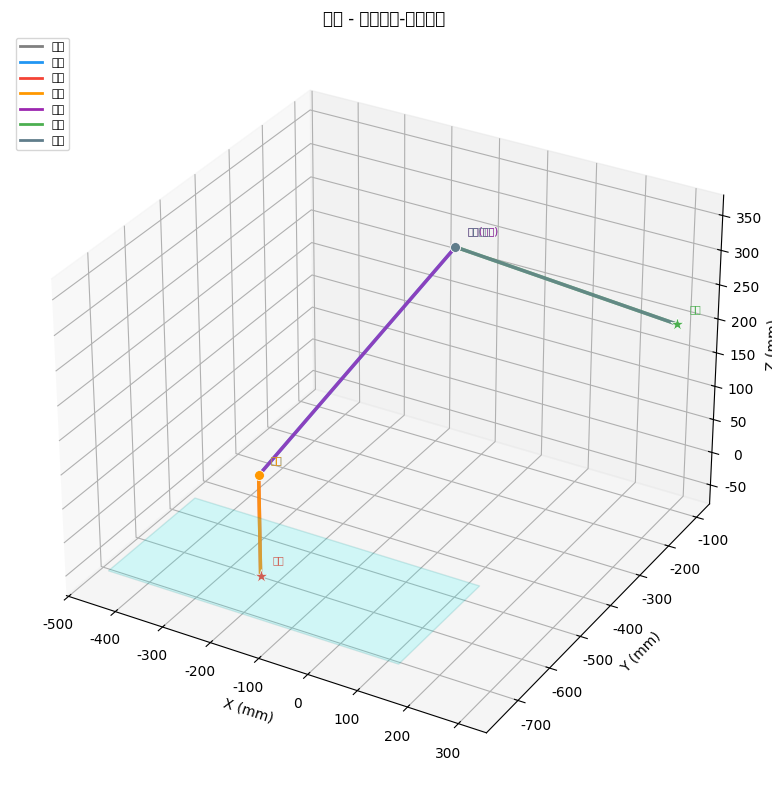

/tmp/ipykernel_195/1500390405.py:85: UserWarning: Glyph 20992 (\N{CJK UNIFIED IDEOGRAPH-5200}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_195/1500390405.py:85: UserWarning: Glyph 26564 (\N{CJK UNIFIED IDEOGRAPH-67C4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_195/1500390405.py:85: UserWarning: Glyph 38218 (\N{CJK UNIFIED IDEOGRAPH-954A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_195/1500390405.py:85: UserWarning: Glyph 23376 (\N{CJK UNIFIED IDEOGRAPH-5B50}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_195/1500390405.py:85: UserWarning: Glyph 21098 (\N{CJK UNIFIED IDEOGRAPH-526A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_195/1500390405.py:85: UserWarning: Glyph 25345 (\N{CJK UNIFIED IDEOGRAPH-6301}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_195/1500390405.py:85: UserWarning: Glyph 38024 (\N{CJK UNIFIED IDEOGRAPH-9488}) missi

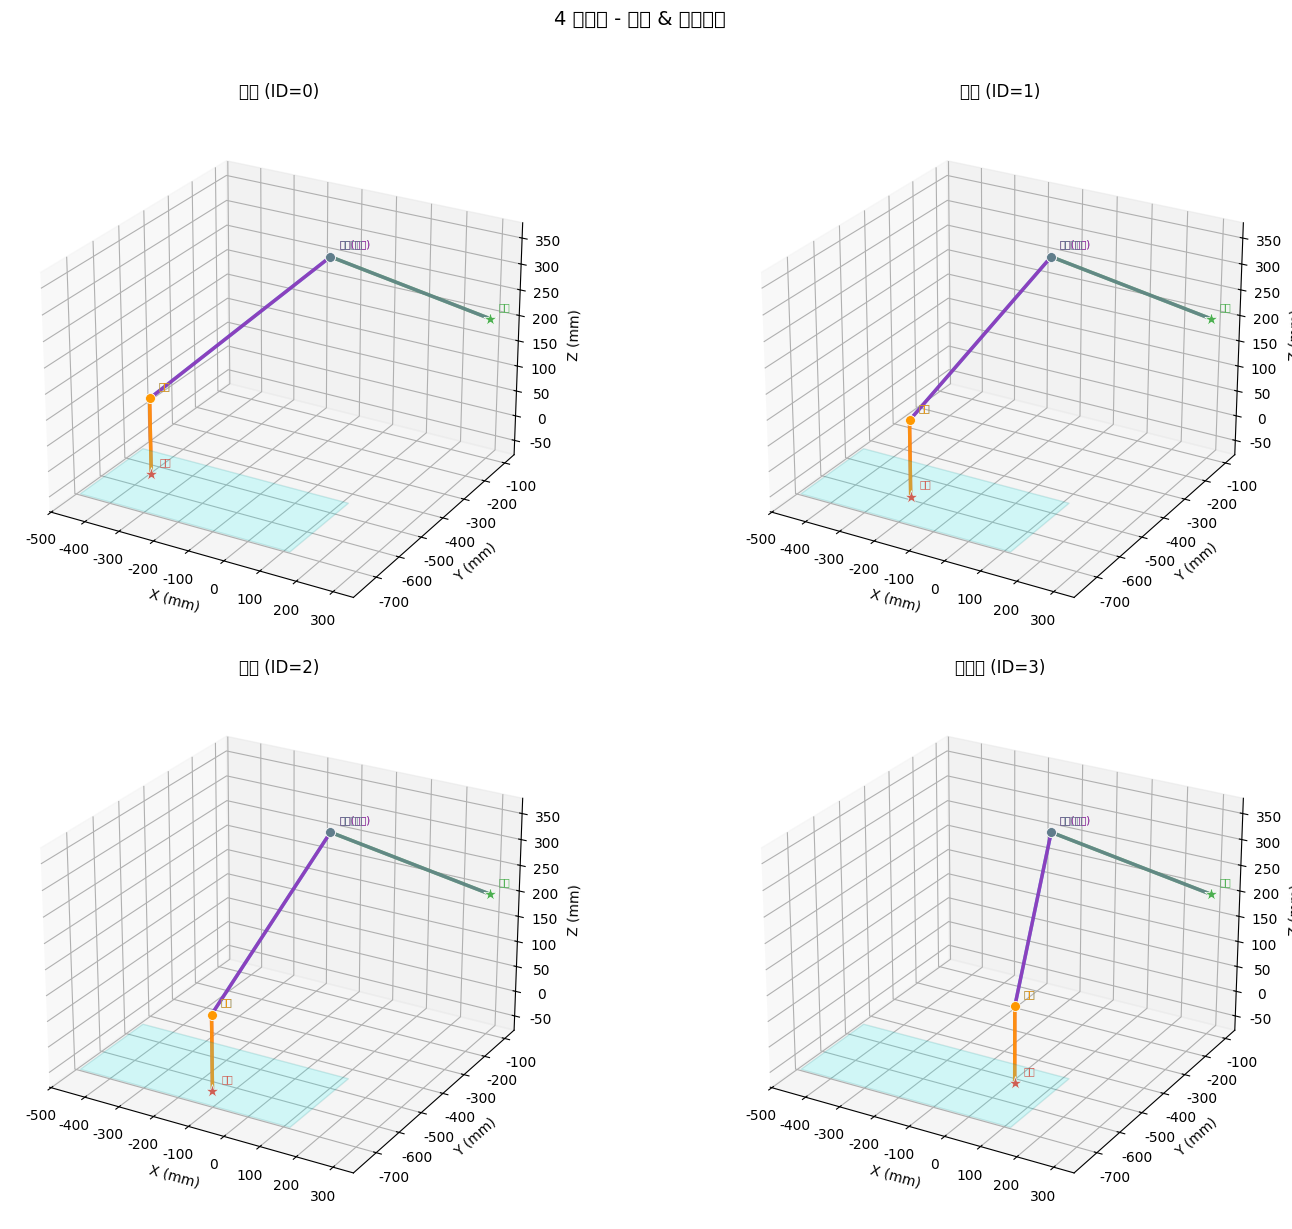

In [25]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# --- 配置中文显示 ---
# 尝试使用'SimHei'，如果不行则回退到Colab的默认中文字体
try:
    plt.rcParams['font.sans-serif'] = ['SimHei', 'WenQuanYi Zen Hei', 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji']
except Exception:
    # Fallback for environments where SimHei isn't available
    pass
plt.rcParams['axes.unicode_minus'] = False # 解决负号显示问题

PHASE_COLORS = {
    'idle': '#808080', 'approach': '#2196F3', 'grasp': '#F44336',
    'lift': '#FF9800', 'transit': '#9C27B0', 'deliver': '#4CAF50',
    'return': '#607D8B',
}
PHASE_CN = {
    'idle': '待机', 'approach': '接近', 'grasp': '抓取',
    'lift': '提升', 'transit': '过渡', 'deliver': '递送', 'return': '返回',
}


def plot_trajectory_3d(trajectory, title='', ax=None):
    show = ax is None
    if ax is None:
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')

    points = [point_to_cartesian(tp.raw_point) for tp in trajectory]

    # 按阶段画线段
    for i in range(len(points) - 1):
        p1, p2 = points[i], points[i + 1]
        phase = trajectory[i + 1].phase
        color = PHASE_COLORS.get(phase, 'gray')
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]],
               color=color, linewidth=2.5, alpha=0.8)

    # 关键点标记
    for tp, pt in zip(trajectory, points):
        color = PHASE_COLORS.get(tp.phase, 'gray')
        ms = 100 if tp.action else 50
        mk = '*' if tp.action else 'o'
        ax.scatter(*pt, c=color, s=ms, marker=mk, zorder=5,
                  edgecolors='white', linewidths=0.5)
        if tp.label:
            ax.text(pt[0]+15, pt[1]+15, pt[2]+15, tp.label,
                   fontsize=7, color=color)

    # 器械托盘区域
    tx = [-450, 150]; ty = [-750, -500]; tz = -50
    verts = [[(tx[0],ty[0],tz),(tx[1],ty[0],tz),(tx[1],ty[1],tz),(tx[0],ty[1],tz)]]
    ax.add_collection3d(Poly3DCollection(verts, alpha=0.15, facecolor='cyan', edgecolor='teal'))

    ax.set_xlabel('X (mm)'); ax.set_ylabel('Y (mm)'); ax.set_zlabel('Z (mm)')
    if title:
        ax.set_title(title, fontsize=12)

    if show:
        from matplotlib.lines import Line2D
        # 使用中文标签
        legend = [Line2D([0],[0], color=c, lw=2, label=PHASE_CN[p])
                  for p, c in PHASE_COLORS.items()]
        ax.legend(handles=legend, loc='upper left', fontsize=8)
        plt.tight_layout()
        plt.show()


# --- 单器械轨迹图 ---
traj_tw = generate_full_trajectory(1, resolver_v2)
plot_trajectory_3d(traj_tw, title='镊子 - 完整拾取-递送轨迹')

# --- 4 器械对比图 ---
fig = plt.figure(figsize=(16, 12))
for idx in range(4):
    ax = fig.add_subplot(2, 2, idx + 1, projection='3d')
    name = INSTRUMENT_MAP[str(idx)]
    traj = generate_full_trajectory(idx, resolver_v2)
    plot_trajectory_3d(traj, title=f'{name} (ID={idx})', ax=ax)
    ax.view_init(elev=25, azim=-60)
fig.suptitle('4 种器械 - 拾取 & 递送轨迹', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
# Part 3: 端到端流程演示

## Cell 11: Mock 硬件层（夹爪、力传感器、日志）

In [26]:
# ============================================================
# Cell 11: Mock 硬件层
# ============================================================

class StepLogger:
    ICONS = {
        'voice': '\U0001f3a4', 'llm': '\U0001f9e0', 'lookup': '\U0001f4cd',
        'arm': '\U0001f9be', 'grip': '\u270a', 'force': '\U0001f590',
        'done': '\u2705', 'error': '\u274c', 'info': '\u2139\ufe0f',
    }

    def __init__(self):
        self.steps = []
        self._start = time.time()

    def log(self, component, action, detail=''):
        icon = self.ICONS.get(component, '')
        self.steps.append({'t': time.time() - self._start,
                           'component': component, 'action': action,
                           'detail': detail, 'icon': icon})

    def print_all(self):
        for s in self.steps:
            d = f" - {s['detail']}" if s['detail'] else ''
            print(f"  {s['icon']} [{s['component']:>6}] {s['action']}{d}")

    def reset(self):
        self.steps.clear()
        self._start = time.time()


class MockGripper:
    def __init__(self):
        self.state = 'open'
        self._qc = 0

    def open_gripper(self, preset_id):
        self.state = 'open'
        return {'status': 'success', 'open_value': GRIPPER_PRESETS.get(preset_id, GRIPPER_PRESETS[-1])['open']}

    def close_gripper(self, preset_id):
        self.state = 'closed'
        self._qc = 0
        p = GRIPPER_PRESETS.get(preset_id, GRIPPER_PRESETS[-1])
        return {'status': 'success', 'close_value': p['close'], 'force': p['force']}

    def get_gripper_status(self):
        self._qc += 1
        return self._qc >= 2


class MockForceSensor:
    def __init__(self, delay_count=3):
        self.enabled = False
        self._qc = 0
        self._delay = delay_count

    def start_detection(self):
        self.enabled = True
        self._qc = 0

    def stop_detection(self):
        self.enabled = False

    def get_force_status(self):
        self._qc += 1
        return {'enabled': self.enabled, 'is_applied': self._qc >= self._delay}


print('Mock 硬件层已定义: StepLogger, MockGripper, MockForceSensor')

Mock 硬件层已定义: StepLogger, MockGripper, MockForceSensor


## Cell 12: MockRobotController（完整流程控制）

对标 `RobotController.handler()` + `robotMove()`，v2 分支跳过 YOLO + 手眼标定。

In [27]:
# ============================================================
# Cell 12: MockRobotController
# 对标: bitRobot/service/RobotController.py
# ============================================================

class MockRobotController:
    """v2 固定位置模式控制器"""

    def __init__(self, arm, gripper, force_sensor, resolver, logger):
        self.arm = arm
        self.gripper = gripper
        self.force_sensor = force_sensor
        self.resolver = resolver
        self.logger = logger

    def handler(self, task):
        instrument_id = task.id
        name = INSTRUMENT_MAP.get(str(instrument_id), '未知')
        self.logger.log('info', f'开始执行: {task.msg_header}, id={instrument_id} ({name})')

        try:
            pos_info = self.resolver.resolve(instrument_id)
        except ValueError as e:
            self.logger.log('error', f'位置查表失败: {e}')
            return False

        self.logger.log('lookup', 'v2查表定位',
                       f"x={pos_info['x']}, y={pos_info['y']}, z={pos_info['z']}, rz={pos_info['rz']}")
        return self._robot_move(pos_info, instrument_id)

    def _robot_move(self, pos_info, instrument_id):
        x, y, z, rz = pos_info['x'], pos_info['y'], pos_info['z'], pos_info['rz']
        name = pos_info['name']

        # 预开夹爪
        self.gripper.open_gripper(instrument_id)
        self.logger.log('grip', '预开夹爪', f'preset_id={instrument_id}')

        # 阶段1: 接近抓取 (对标 robotMove line 71-84)
        self.logger.log('arm', '阶段1-接近', '悬停 -> 下降')
        self.arm.set_phase('approach', '悬停')
        self.arm.execute_path([[x, y, z+Z_HOVER, FIXED_RX, FIXED_RY, rz, 0]])
        self.arm.set_phase('grasp', '抓取')
        self.arm.execute_path([[x, y, z+Z_GRASP, FIXED_RX, FIXED_RY, rz, 0]])

        # 夹取
        result = self.gripper.close_gripper(instrument_id)
        self.logger.log('grip', '夹爪闭合', f"force={result['force']}")
        while not self.gripper.get_gripper_status():
            pass
        self.logger.log('arm', f'已抓取{name}')

        # 阶段2: 递送 (对标 robotMove line 102-113)
        self.logger.log('arm', '阶段2-递送', '提升 -> 复位 -> 递送')
        self.arm.set_phase('lift', '提升')
        self.arm.execute_path([[x, y, z+Z_HOVER, FIXED_RX, FIXED_RY, rz, 0]])
        self.arm.set_phase('transit', '过渡')
        self.arm.execute_path([RESET_POINT])
        self.arm.set_phase('deliver', '递送')
        self.arm.execute_path([TARGET_POINT])
        self.logger.log('arm', '已到达递送位置')

        # 阶段3: 力检测 -> 释放 -> 复位 (对标 robotMove line 118-155)
        self.force_sensor.start_detection()
        self.logger.log('force', '开启力检测', '等待医生取走器械...')
        while True:
            if self.force_sensor.get_force_status()['is_applied']:
                break
        self.logger.log('force', '检测到外力', '松开夹爪')
        self.gripper.open_gripper(-1)
        self.force_sensor.stop_detection()
        self.logger.log('arm', f'{name}已被取走')

        self.logger.log('arm', '阶段3-复位', '返回预备姿态')
        self.arm.set_phase('return', '最终复位')
        self.arm.execute_path([RESET_POINT])
        self.logger.log('done', '已恢复到预备姿态')
        return True


print('MockRobotController 已定义')

MockRobotController 已定义


## Cell 13: PipelineRunner（流程编排引擎）

组装所有组件，提供 `run(voice_text)` 一键执行完整流程。

/tmp/ipykernel_195/1500390405.py:68: UserWarning: Glyph 38218 (\N{CJK UNIFIED IDEOGRAPH-954A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_195/1500390405.py:68: UserWarning: Glyph 23376 (\N{CJK UNIFIED IDEOGRAPH-5B50}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_195/1500390405.py:68: UserWarning: Glyph 36816 (\N{CJK UNIFIED IDEOGRAPH-8FD0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_195/1500390405.py:68: UserWarning: Glyph 21160 (\N{CJK UNIFIED IDEOGRAPH-52A8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_195/1500390405.py:68: UserWarning: Glyph 36712 (\N{CJK UNIFIED IDEOGRAPH-8F68}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_195/1500390405.py:68: UserWarning: Glyph 36857 (\N{CJK UNIFIED IDEOGRAPH-8FF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_195/1500390405.py:68: UserWarning: Glyph 24453 (\N{CJK UNIFIED IDEOGRAPH-5F85}) missi


流程执行日志:
  🎤 [ voice] 语音输入 - 传递镊子
  🧠 [   llm] LLM解析 - 器件, id=1 (镊子)
  ℹ️ [  info] 开始执行: 器件, id=1 (镊子)
  📍 [lookup] v2查表定位 - x=-200.0, y=-650.0, z=-48.0, rz=30.0
  ✊ [  grip] 预开夹爪 - preset_id=1
  🦾 [   arm] 阶段1-接近 - 悬停 -> 下降
  ✊ [  grip] 夹爪闭合 - force=980
  🦾 [   arm] 已抓取镊子
  🦾 [   arm] 阶段2-递送 - 提升 -> 复位 -> 递送
  🦾 [   arm] 已到达递送位置
  🖐 [ force] 开启力检测 - 等待医生取走器械...
  🖐 [ force] 检测到外力 - 松开夹爪
  🦾 [   arm] 镊子已被取走
  🦾 [   arm] 阶段3-复位 - 返回预备姿态
  ✅ [  done] 已恢复到预备姿态


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 36816 (\N{CJK UNIFIED IDEOGRAPH-8FD0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21160 (\N{CJK UNIFIED IDEOGRAPH-52A8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


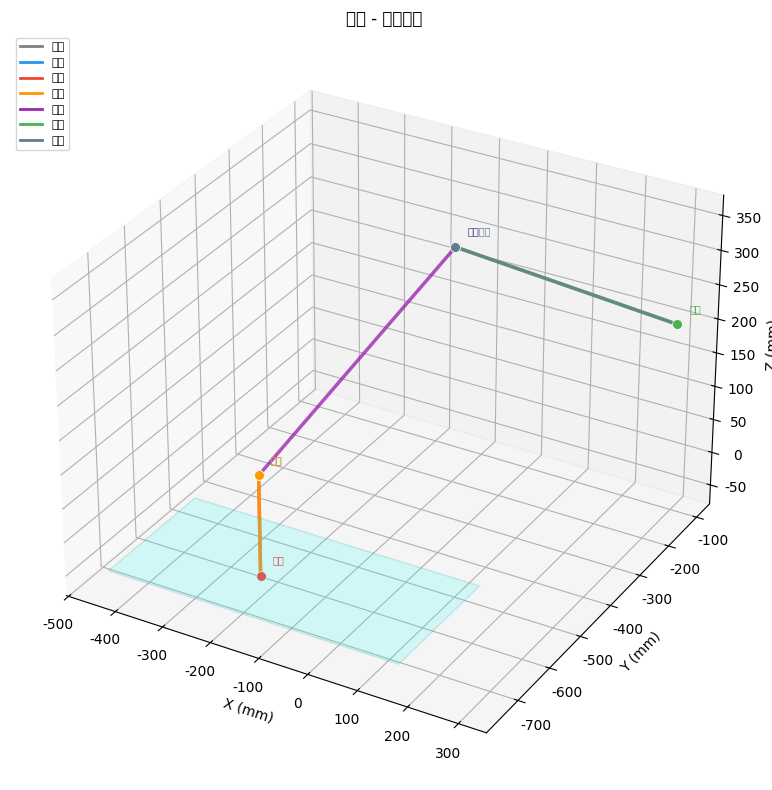

{'success': True,
 'logs': [{'t': 8.106231689453125e-06,
   'component': 'voice',
   'action': '语音输入',
   'detail': '传递镊子',
   'icon': '🎤'},
  {'t': 3.266334533691406e-05,
   'component': 'llm',
   'action': 'LLM解析',
   'detail': '器件, id=1 (镊子)',
   'icon': '🧠'},
  {'t': 4.0531158447265625e-05,
   'component': 'info',
   'action': '开始执行: 器件, id=1 (镊子)',
   'detail': '',
   'icon': 'ℹ️'},
  {'t': 5.4836273193359375e-05,
   'component': 'lookup',
   'action': 'v2查表定位',
   'detail': 'x=-200.0, y=-650.0, z=-48.0, rz=30.0',
   'icon': '📍'},
  {'t': 6.365776062011719e-05,
   'component': 'grip',
   'action': '预开夹爪',
   'detail': 'preset_id=1',
   'icon': '✊'},
  {'t': 6.604194641113281e-05,
   'component': 'arm',
   'action': '阶段1-接近',
   'detail': '悬停 -> 下降',
   'icon': '🦾'},
  {'t': 0.00010728836059570312,
   'component': 'grip',
   'action': '夹爪闭合',
   'detail': 'force=980',
   'icon': '✊'},
  {'t': 0.00011205673217773438,
   'component': 'arm',
   'action': '已抓取镊子',
   'detail': '',
   '

In [28]:
# ============================================================
# Cell 13: PipelineRunner
# ============================================================

class PipelineRunner:
    def __init__(self):
        self.config_loader = ConfigLoader(INSTRUMENTS_INI_CONTENT)
        self.llm = MockLLMService(self.config_loader)
        self.resolver = PositionResolver(self.config_loader)
        self.arm = MockRobotArm()
        self.gripper = MockGripper()
        self.force_sensor = MockForceSensor(delay_count=3)
        self.logger = StepLogger()
        self.controller = MockRobotController(
            self.arm, self.gripper, self.force_sensor, self.resolver, self.logger
        )

    def run(self, voice_text, show_trajectory=False):
        self.logger.reset()
        self.arm.clear_trajectory()

        self.logger.log('voice', '语音输入', voice_text)

        result = self.llm.process_cmd_text(voice_text)
        if isinstance(result, str):
            task = TaskInfo(msg_header=result, id=-1)
        else:
            if result[1] == -1:
                self.logger.log('llm', '解析结果', '语音不包含医疗器械，停止后续操作')
                self.logger.log('error', '流程终止')
                self._print_result()
                return {'success': False, 'logs': self.logger.steps}
            task = TaskInfo(msg_header=result[0], id=result[1])

        name = INSTRUMENT_MAP.get(str(task.id), task.msg_header)
        self.logger.log('llm', 'LLM解析', f'{task.msg_header}, id={task.id} ({name})')

        success = False
        if task.msg_header == '器件':
            success = self.controller.handler(task)
        elif task.msg_header == '统计':
            self.logger.log('info', '执行统计', '扫描所有槽位...')
            all_inst = self.config_loader.get_all()
            summary = ', '.join([f'{v.name}: 槽位{k}' for k, v in all_inst.items()])
            self.logger.log('done', f'统计完成: 共{len(all_inst)}种器械', summary)
            success = True
        elif task.msg_header == '清点':
            self.logger.log('info', '执行清点', '对比基准数据...')
            self.logger.log('done', '清点完成: 所有器械数量匹配')
            success = True
        elif task.msg_header == '取消':
            self.logger.log('info', '执行取消', '停止当前操作')
            self.logger.log('done', '已恢复到预备姿态')
            success = True

        self._print_result()
        if show_trajectory and self.arm.get_trajectory():
            plot_trajectory_3d(self.arm.get_trajectory(), title=f'{name} - 运动轨迹')

        return {'success': success, 'logs': self.logger.steps,
                'trajectory': self.arm.get_trajectory()}

    def _print_result(self):
        print('\n' + '=' * 50)
        print('流程执行日志:')
        print('=' * 50)
        self.logger.print_all()
        print('=' * 50)


# --- 快速验证 ---
pipeline = PipelineRunner()
pipeline.run('传递镊子', show_trajectory=True)

## Cell 14: 交互式演示

输入语音文本，观察完整的模拟流程。

**试试输入**: `传递镊子` / `给我剪刀` / `刀柄` / `持针钳` / `统计` / `清点` / `取消` / `你好`

### 中文字体支持说明（已更新）

为了彻底解决matplotlib图表中中文字符显示不正确的问题，我采取了以下步骤：

1.  **安装中文字体**：在 Colab 环境中安装了 `fonts-wqy-zenhei` 字体包。这确保了环境中存在支持中文的字体。
    ```bash
    !sudo apt-get install -y fonts-wqy-zenhei
    ```
2.  **配置 `matplotlib` 使用中文字体**：在绘图代码中，通过 `plt.rcParams` 将默认的无衬线字体设置为 `WenQuanYi Zen Hei`，并保留其他常用字体作为备选。同时，设置 `axes.unicode_minus` 为 `False` 以解决负号显示为方框的问题。
    ```python
    plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei', 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji']
    plt.rcParams['axes.unicode_minus'] = False
    ```

完成这些步骤后，图表应该能够稳定地显示中文字符，并且可以避免之前可能出现的 `UserWarning: Glyph ... missing from font(s) DejaVu Sans.` 警告。
**注意：在较新版本的 `matplotlib` 中，`matplotlib.font_manager._rebuild()` 方法可能已被移除。通常，安装字体后，重新运行相关的绘图单元格，或者重启 Colab 运行时，`matplotlib` 会自动检测到新字体。**

In [33]:
# ============================================================
# Cell 14.1: 安装中文字体并重建matplotlib字体缓存
# (此步骤确保环境中有中文字体并让matplotlib识别)
# ============================================================

# 安装文泉驿正黑字体
!sudo apt-get install -y fonts-wqy-zenhei > /dev/null

# 导入matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# 在当前Matplotlib版本中，fm.get_cachedir() 已被移除，且通常不需要手动清除字体缓存。
# fm._load_fontmanager(try_read_cache=False) 会在必要时重建缓存。
# 因此，移除以下清理缓存的代码块。
# cache_dir = fm.get_cachedir()
# for f in os.listdir(cache_dir):
#     if f.startswith('fontlist-'):
#         os.remove(os.path.join(cache_dir, f))
# print(f"清除了matplotlib字体缓存目录: {cache_dir}")

print("跳过手动清除字体缓存步骤，依赖matplotlib的自动重建机制。")

# 重建matplotlib字体缓存
fm._load_fontmanager(try_read_cache=False)

# 再次尝试找到字体并打印路径 (用于调试)
font_found = False
for font_path in fm.findSystemFonts(fontpaths=None, fontext='ttf'):
    if 'wqy-zenhei' in os.path.basename(font_path).lower(): # Case-insensitive check for wqy-zenhei
        print(f"找到文泉驿字体: {font_path}")
        font_found = True
        break

if not font_found:
    print("警告: 未能在系统字体中找到文泉驿正黑字体，请检查安装是否成功。")

print('中文字体安装完成。后续单元格中的图表将正常显示中文。')


跳过手动清除字体缓存步骤，依赖matplotlib的自动重建机制。
找到文泉驿字体: /usr/share/fonts/truetype/wqy/wqy-zenhei.ttc
中文字体安装完成。后续单元格中的图表将正常显示中文。


## Cell 15: 流程时序图

将执行流程可视化为甘特图风格的时序图。


流程执行日志:
  🎤 [ voice] 语音输入 - 刀柄
  🧠 [   llm] LLM解析 - 器件, id=0 (刀柄)
  ℹ️ [  info] 开始执行: 器件, id=0 (刀柄)
  📍 [lookup] v2查表定位 - x=-350.0, y=-600.0, z=-48.5, rz=45.0
  ✊ [  grip] 预开夹爪 - preset_id=0
  🦾 [   arm] 阶段1-接近 - 悬停 -> 下降
  ✊ [  grip] 夹爪闭合 - force=800
  🦾 [   arm] 已抓取刀柄
  🦾 [   arm] 阶段2-递送 - 提升 -> 复位 -> 递送
  🦾 [   arm] 已到达递送位置
  🖐 [ force] 开启力检测 - 等待医生取走器械...
  🖐 [ force] 检测到外力 - 松开夹爪
  🦾 [   arm] 刀柄已被取走
  🦾 [   arm] 阶段3-复位 - 返回预备姿态
  ✅ [  done] 已恢复到预备姿态


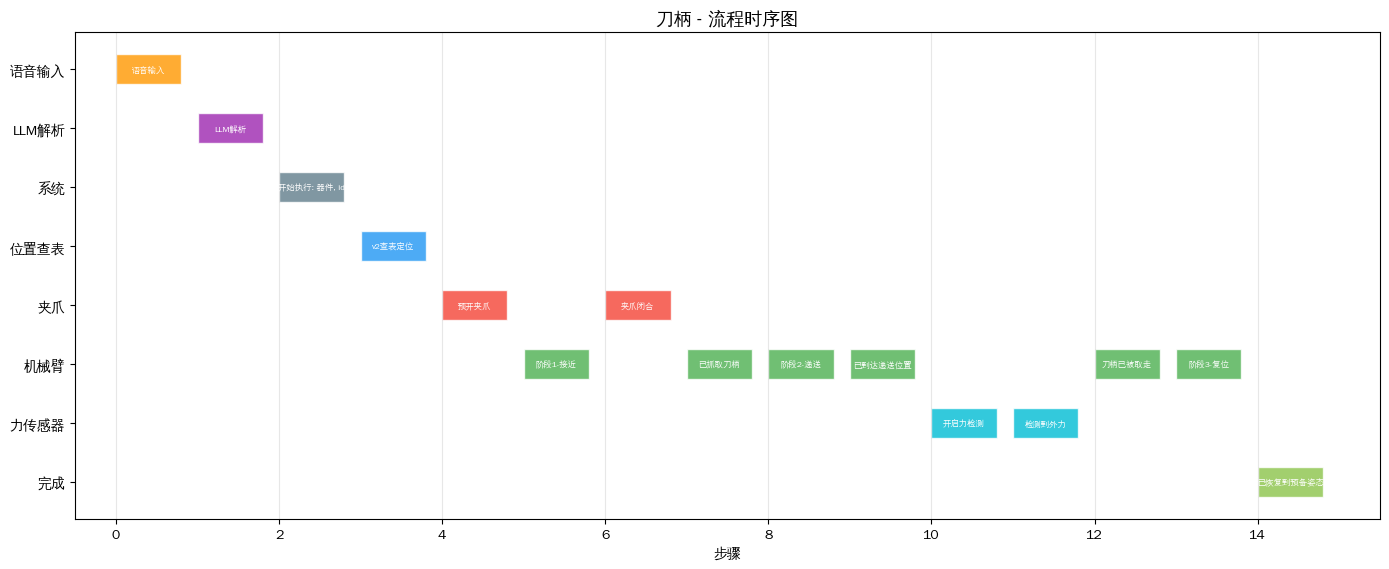


流程执行日志:
  🎤 [ voice] 语音输入 - 镊子
  🧠 [   llm] LLM解析 - 器件, id=1 (镊子)
  ℹ️ [  info] 开始执行: 器件, id=1 (镊子)
  📍 [lookup] v2查表定位 - x=-200.0, y=-650.0, z=-48.0, rz=30.0
  ✊ [  grip] 预开夹爪 - preset_id=1
  🦾 [   arm] 阶段1-接近 - 悬停 -> 下降
  ✊ [  grip] 夹爪闭合 - force=980
  🦾 [   arm] 已抓取镊子
  🦾 [   arm] 阶段2-递送 - 提升 -> 复位 -> 递送
  🦾 [   arm] 已到达递送位置
  🖐 [ force] 开启力检测 - 等待医生取走器械...
  🖐 [ force] 检测到外力 - 松开夹爪
  🦾 [   arm] 镊子已被取走
  🦾 [   arm] 阶段3-复位 - 返回预备姿态
  ✅ [  done] 已恢复到预备姿态


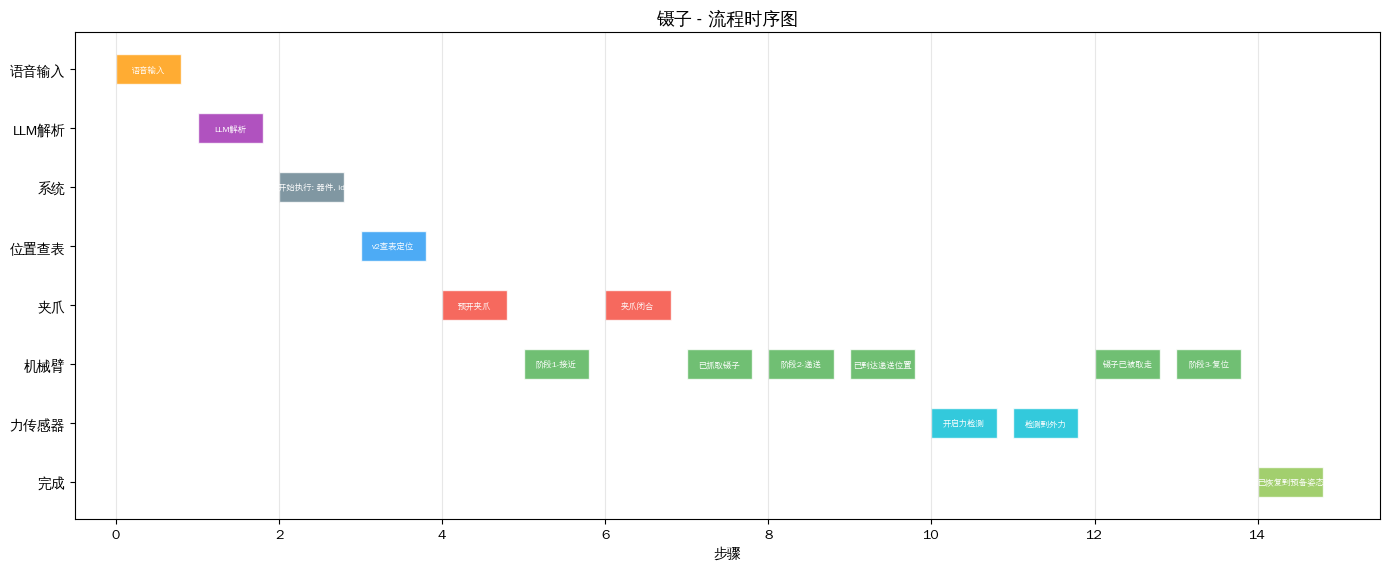


流程执行日志:
  🎤 [ voice] 语音输入 - 剪刀
  🧠 [   llm] LLM解析 - 器件, id=2 (剪刀)
  ℹ️ [  info] 开始执行: 器件, id=2 (剪刀)
  📍 [lookup] v2查表定位 - x=-100.0, y=-700.0, z=-49.0, rz=60.0
  ✊ [  grip] 预开夹爪 - preset_id=2
  🦾 [   arm] 阶段1-接近 - 悬停 -> 下降
  ✊ [  grip] 夹爪闭合 - force=550
  🦾 [   arm] 已抓取剪刀
  🦾 [   arm] 阶段2-递送 - 提升 -> 复位 -> 递送
  🦾 [   arm] 已到达递送位置
  🖐 [ force] 开启力检测 - 等待医生取走器械...
  🖐 [ force] 检测到外力 - 松开夹爪
  🦾 [   arm] 剪刀已被取走
  🦾 [   arm] 阶段3-复位 - 返回预备姿态
  ✅ [  done] 已恢复到预备姿态


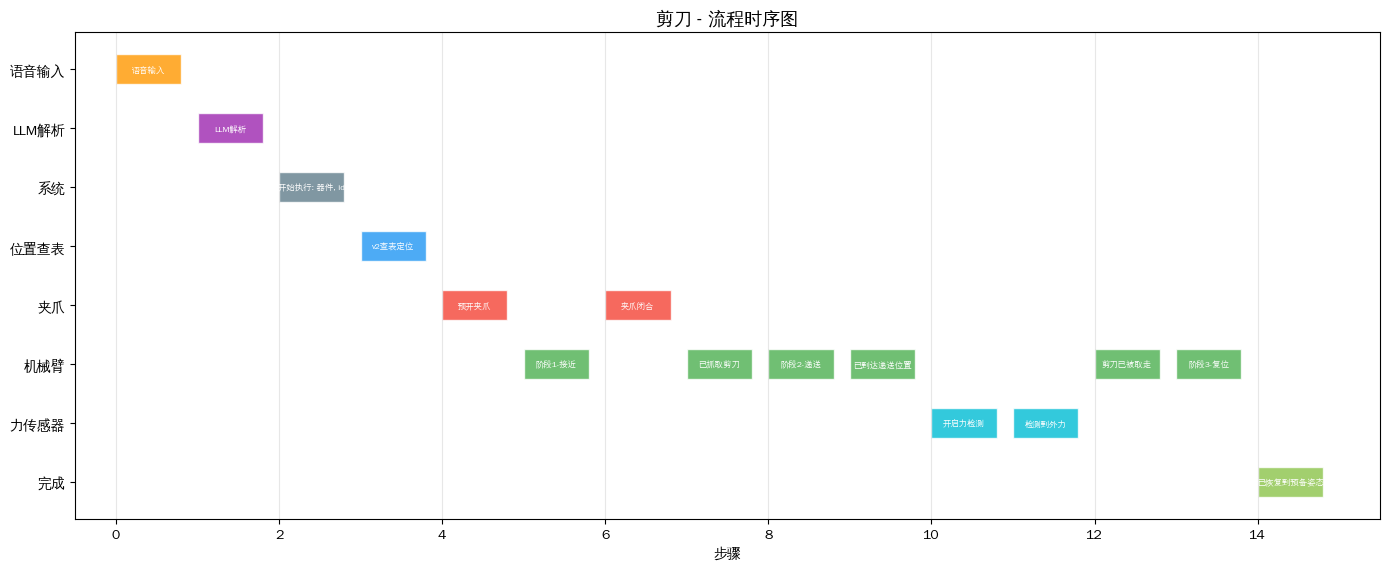


流程执行日志:
  🎤 [ voice] 语音输入 - 持针钳
  🧠 [   llm] LLM解析 - 器件, id=3 (持针钳)
  ℹ️ [  info] 开始执行: 器件, id=3 (持针钳)
  📍 [lookup] v2查表定位 - x=50.0, y=-580.0, z=-48.8, rz=15.0
  ✊ [  grip] 预开夹爪 - preset_id=3
  🦾 [   arm] 阶段1-接近 - 悬停 -> 下降
  ✊ [  grip] 夹爪闭合 - force=800
  🦾 [   arm] 已抓取持针钳
  🦾 [   arm] 阶段2-递送 - 提升 -> 复位 -> 递送
  🦾 [   arm] 已到达递送位置
  🖐 [ force] 开启力检测 - 等待医生取走器械...
  🖐 [ force] 检测到外力 - 松开夹爪
  🦾 [   arm] 持针钳已被取走
  🦾 [   arm] 阶段3-复位 - 返回预备姿态
  ✅ [  done] 已恢复到预备姿态


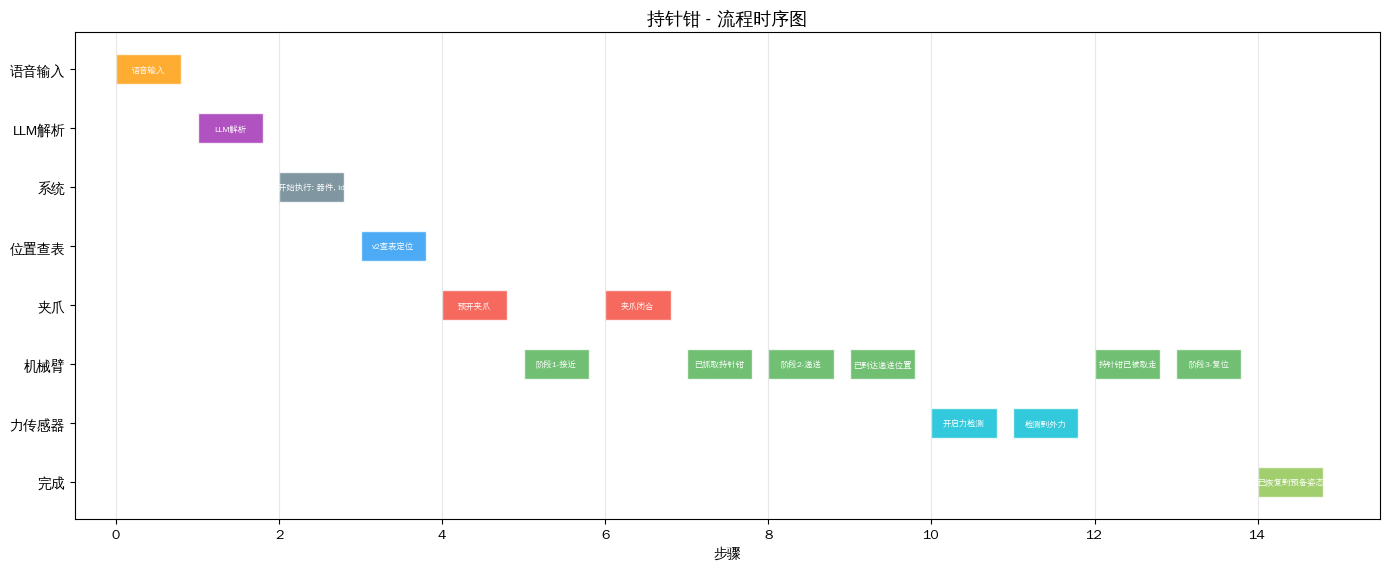


所有器械流程时序图绘制完成


In [35]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# ============================================================
# Cell 15: 流程时序图
# ============================================================

def plot_timeline(logs, title='流程时序图'):
    if not logs:
        print('无日志数据')
        return

    # 查找并添加文泉驿字体文件到matplotlib的font_manager
    font_path = None
    for fpath in fm.findSystemFonts(fontpaths=None, fontext='ttf'):
        if 'wqy-zenhei' in os.path.basename(fpath).lower():
            font_path = fpath
            break

    if font_path:
        fm.fontManager.addfont(font_path)
        # 确保中文字体已加载并设置为首选
        plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei', 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji']
        plt.rcParams['axes.unicode_minus'] = False # 解决负号显示问题
    else:
        print("警告: 未找到文泉驿正黑字体，中文可能无法正常显示。")
        plt.rcParams['axes.unicode_minus'] = False # 解决负号显示问题


    comp_labels = {
        'voice': '语音输入', 'llm': 'LLM解析', 'lookup': '位置查表',
        'arm': '机械臂', 'grip': '夹爪', 'force': '力传感器',
        'done': '完成', 'error': '错误', 'info': '系统',
    }
    comp_colors = {
        'voice': '#FF9800', 'llm': '#9C27B0', 'lookup': '#2196F3',
        'arm': '#4CAF50', 'grip': '#F44336', 'force': '#00BCD4',
        'done': '#8BC34A', 'error': '#F44336', 'info': '#607D8B',
    }

    seen = []
    for log in logs:
        if log['component'] not in seen:
            seen.append(log['component'])

    fig, ax = plt.subplots(figsize=(14, max(3, len(seen) * 0.6 + 1)))
    y_map = {c: i for i, c in enumerate(reversed(seen))}

    for i, log in enumerate(logs):
        comp = log['component']
        y = y_map[comp]
        color = comp_colors.get(comp, 'gray')
        ax.barh(y, width=0.8, left=i, height=0.5, color=color, alpha=0.8, edgecolor='white')
        action_short = log['action'][:12]
        ax.text(i + 0.4, y, action_short, ha='center', va='center',
               fontsize=6, color='white', fontweight='bold')

    ax.set_yticks(range(len(seen)))
    ax.set_yticklabels([comp_labels.get(c, c) for c in reversed(seen)], fontsize=10)
    ax.set_xlabel('步骤', fontsize=10) # Change to Chinese
    ax.set_title(title, fontsize=13)
    ax.set_xlim(-0.5, len(logs) + 0.5)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()


# --- 运行 4 种器械并绘制时序图 ---
for inst_name in ['刀柄', '镊子', '剪刀', '持针钳']:
    pv = PipelineRunner()
    result = pv.run(inst_name, show_trajectory=False)
    plot_timeline(result['logs'], title=f'{inst_name} - 流程时序图')

print('\n所有器械流程时序图绘制完成')
